# 3b. Circulation analogues
The workflow for the circulation analogues is close to final, apart from links to software. It will be
added in the next deliverable D451.2.3.2. Some of the main steps will include:
- Identification of the domain to calculate analogues.
- Assessment on which circulation variable to use.
- Assessment of composites of analogues.
- Assessment of change in frequency of analogues.

In [1]:
# Imports
# import analogue_functions_C3S as my
import c3s_lib.analogue_functions_C3S as my

from c3s_lib import *
import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx
from typing import Union, Literal
import os
import iris
import iris.coords as icoords
import cftime
import cf_units
from iris.cube import Cube
import scipy.stats as stats
import calendar
import numpy.ma as ma

In [2]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
################# (User selection) ###################
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'
######################################################

# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file

################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################
os.makedirs(your_save_directory, exist_ok=True) # create directory if it does not exist

## 3.8 Make sure the software reads the four key variables from the event definition (probabilistic attribution):
- a. Event date, this is a single day. This should be the date where the hazard has the highest magnitude. This needs a manual decision based on the event definition of the probabilistic attribution, see figures from Step 2.13
- b. Hazard variable, either (hot or cold) temperature (t2m) (If possible needs to be changed to become Tmax, t2m or Tmin, depending on the probabilistic event definition.) or rainfall (tp)
- c. Probabilistic event region, used to define the hazard of the event, for plotting. This could be a shapefile or latitude/longitude boundaries of a box, saved in Step 2.3.
- d. Needs to be changed to reading in the event time series (daily series) from the probabilistic event definition.

### <font color='orange'>Please specify the following variables below to start the workflow</font>

In [3]:
# geopandas region min lon, min lat, max lon, max lat
impact_domain = (-61, -36, -56, -32)
# iris [N, S, W, E]
impact_domain_iris = [-32, -36, -56, -61]
z500_domain = (-70, -30, -55, -20)
z500_domain_iris = [-20, -55, -30, -70] 
slp_domain = (-80, -35, -55, -25)
slp_domain_iris = [-25, -55, -35, -80] 

slp_domain = z500_domain
slp_domain_iris = z500_domain_iris

# date
event_date = datetime(2023, 3, 11)
iris_date = [2023, 'Mar', 11] 

# variable
parameter = "Tmean"
Haz = "t2m"

start_period = datetime(1950, 1, 1)
end_period = datetime(2025, 6, 30)

start_period = datetime(2000, 1, 1)
end_period = datetime(2005, 12, 31)

In [ ]:
months = ["Mar", "Apr", "May"]

gdf = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter=parameter, bbox=impact_domain, time_range=(start_period, end_period), months=months, to_unit="c")

Connected to: https://beacon-era5.maris.nl/ server successfully
Connected to: https://beacon-era5.maris.nl/ server successfully
Fetching data from beacon cache...
Beacon Bbox: (299.0, -36, 304.0, -32)
Running query: {"from": "daily", "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 299.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 304.0}, {"column": "latitude", "gt_eq": -36, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": -32}]}, {"column": "valid_time", "gt_eq": "2000-01-01T00:00:00.000000", "lt_eq": "2005-12-31T00:00:00.000000"}], "output": {"format": "parquet"}}


In [8]:
gdf

,longitude,latitude,valid_time,t2m,geometry
0,-61.0,-36.00,2000-01-01,25.367340,POINT (-61 -36)
1,-61.0,-35.75,2000-01-01,25.688721,POINT (-61 -35.75)
2,-61.0,-35.50,2000-01-01,26.046295,POINT (-61 -35.5)
3,-61.0,-35.25,2000-01-01,26.239899,POINT (-61 -35.25)
4,-61.0,-35.00,2000-01-01,25.842529,POINT (-61 -35)
...,...,...,...,...,...
782539,-56.0,-33.00,2005-12-31,22.938843,POINT (-56 -33)
782540,-56.0,-32.75,2005-12-31,23.313507,POINT (-56 -32.75)
782541,-56.0,-32.50,2005-12-31,23.584259,POINT (-56 -32.5)
782542,-56.0,-32.25,2005-12-31,23.431580,POINT (-56 -32.25)


Load in data

In [ ]:
# The selected study region for the Event definition
# shapefile location
studyregion_file = os.path.join(your_save_directory, "sf_studyregion.shp")
# import shapefile as gdf
studyregion = gpd.read_file(studyregion_file)
# extract the polygons
polygons = studyregion.geometry

# use these variables for now
# get daily data for region (world?) and time period 1950 - 2025?
start_period = datetime(2023, 1, 1) # for testing
end_period = datetime(2023, 12, 31) # for testing


# daily variable data
gr_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter=parameter, bbox=impact_domain, time_range=(start_period, end_period), to_unit="c")
# daily z500 data
z500_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter="z500", bbox=z500_domain, time_range=(start_period, end_period), to_unit="c")
# daily slp data
slp_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter="slp", bbox=slp_domain, time_range=(start_period, end_period), to_unit="c")

Connected to: https://beacon-era5.maris.nl/ server successfully
Connected to: https://beacon-era5.maris.nl/ server successfully
Fetching data from beacon cache...
Beacon Bbox: (299.0, -36, 304.0, -32)
Running query: {"from": "era5_daily_mean_2m_temperature", "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 299.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 304.0}, {"column": "latitude", "gt_eq": -36, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": -32}]}, {"column": "valid_time", "gt_eq": "2023-01-01T00:00:00.000000", "lt_eq": "2023-12-31T00:00:00.000000"}], "output": {"format": "parquet"}}
Beacon cache covers time range: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Connected to: https://beacon-era5.maris.nl/ server successfully
Connected to: https://beacon-era5.maris.nl/ server success

2025-11-26 10:17:02,312 INFO Request ID is d2000f59-cf37-4670-839a-f1c3a59e6fdc
2025-11-26 10:17:02,380 INFO status has been updated to accepted
2025-11-26 10:21:39,533 INFO status has been updated to successful


Connected to: https://beacon-era5.maris.nl/ server successfully
Connected to: https://beacon-era5.maris.nl/ server successfully


2025-11-26 10:21:41,460 INFO Request ID is f35d13d9-c406-47cc-b985-7e9d1d8bc296
2025-11-26 10:21:41,521 INFO status has been updated to accepted
2025-11-26 10:22:16,577 INFO status has been updated to running
2025-11-26 10:37:01,997 INFO status has been updated to successful


## 3.9 Identify domains to calculate analogues over:
- a. Action: run script C3S01_analogues_Domain.ipynb
    - i. This step requires input of the initial variables (Step 3.8), and assessment of the analogue domains by re-running the final cell.
    - ii. Software creates plots with correlations to decide on the analogues domain Supp.Fig.1 (see Figures description section)
- b. Action: determine the domains, by manually assessing Supp.Fig.1
    - i. Use the 3-month window around the event unless there is a clear reason to deviate
    - ii. Software calculates the correlation between the event time series and Z500 as well as msl
    - iii. Software produces Z500 and msl figures showing correlation with event time series as well as the event domain
    - iv. Software produces Z500 and msl figures showing correlation with event time series as well as a chosen domain, indicating the ratio blue/red; Supp.Fig.1 (see Figures description section)
        - 9.b.iv.1. Choose a domain (box) which covers the region of greatest correlation in absolute terms (furthest from zero). See Figures Description for an example. The domain is likely to differ for each variable (Z500 and msl).
        - 9.b.iv.2. Re-run until the cell of ratios of red/blue to test different options until the ratios are between 0.2 and 0.3
        - 9.b.iv.2.1. Some events may need expert judgement and a different ratio. Especially precipitation events need some more thorough testing/judgement.
- c. Action: check the final text output, which shows the details of the event and provides inputs for next stages (analogues domains)

In [ ]:
z500_daily

,valid_time,pressure_level,latitude,longitude,z,number,geometry
0,2023-01-01,500.0,-20.0,-70.00,57634.847656,0,POINT (-70 -20)
1,2023-01-01,500.0,-20.0,-69.75,57628.609375,0,POINT (-69.75 -20)
2,2023-01-01,500.0,-20.0,-69.50,57646.421875,0,POINT (-69.5 -20)
3,2023-01-01,500.0,-20.0,-69.25,57630.410156,0,POINT (-69.25 -20)
4,2023-01-01,500.0,-20.0,-69.00,57623.160156,0,POINT (-69 -20)
...,...,...,...,...,...,...,...
912860,2023-12-31,500.0,-30.0,-56.00,57284.730469,0,POINT (-56 -30)
912861,2023-12-31,500.0,-30.0,-55.75,57276.875000,0,POINT (-55.75 -30)
912862,2023-12-31,500.0,-30.0,-55.50,57263.230469,0,POINT (-55.5 -30)
912863,2023-12-31,500.0,-30.0,-55.25,57254.687500,0,POINT (-55.25 -30)


## Turn the gdfs into iris cubes

In [ ]:
def gdf_to_cube(gdf, var_name='t2m'):
    gdf['valid_time'] = pd.to_datetime(gdf['valid_time'])
    gdf = gdf.sort_values(['valid_time', 'latitude', 'longitude'])

    lats = np.sort(gdf['latitude'].unique())
    lons = np.sort(gdf['longitude'].unique())
    times = pd.to_datetime(gdf['valid_time'].unique())

    time_unit = cf_units.Unit('days since 1970-01-01', calendar='gregorian')
    time_points = time_unit.date2num(times.to_pydatetime())

    lat_coord = icoords.DimCoord(lats, standard_name='latitude', units='degrees')
    lon_coord = icoords.DimCoord(lons, standard_name='longitude', units='degrees')
    time_coord = icoords.DimCoord(time_points, standard_name='time', units=time_unit)

    data = (
        gdf.pivot_table(index='valid_time', columns=['latitude', 'longitude'], values=var_name)
        .to_numpy()
        .reshape(len(times), len(lats), len(lons))
    )

    cube = Cube(
        data,
        dim_coords_and_dims=[(time_coord, 0), (lat_coord, 1), (lon_coord, 2)],
        standard_name="air_temperature",
        var_name=var_name,
        units="degC",
    )

    return cube


In [ ]:
gr_daily_cube = gdf_to_cube(gr_daily, var_name='t2m')

gr_daily_cube

Air Temperature (degC),time,latitude,longitude
Shape,365,17,21
Dimension coordinates,,,
time,x,-,-
latitude,-,x,-
longitude,-,-,x


In [ ]:
def gdf_to_cube_z500(gdf, var_name='z'):
    """
    Convert a gridded GeoDataFrame (with pressure levels) to an Iris Cube.
    Expected columns: valid_time, pressure_level, latitude, longitude, <var_name>
    """
    # Ensure datetime
    gdf['valid_time'] = pd.to_datetime(gdf['valid_time'])

    # Sort for consistency
    gdf = gdf.sort_values(['valid_time', 'pressure_level', 'latitude', 'longitude'])

    # Unique coordinates
    times = pd.to_datetime(gdf['valid_time'].unique())
    levs = np.sort(gdf['pressure_level'].unique())
    lats = np.sort(gdf['latitude'].unique())
    lons = np.sort(gdf['longitude'].unique())

    # Time coordinate (convert to numeric)
    time_unit = cf_units.Unit('days since 1970-01-01', calendar='gregorian')
    time_points = time_unit.date2num(times.to_pydatetime())

    # Create DimCoords
    time_coord = icoords.DimCoord(time_points, standard_name='time', units=time_unit)
    lev_coord = icoords.DimCoord(levs, standard_name='air_pressure', units='hPa')
    lat_coord = icoords.DimCoord(lats, standard_name='latitude', units='degrees')
    lon_coord = icoords.DimCoord(lons, standard_name='longitude', units='degrees')

    # Pivot data into 4D array: (time, level, lat, lon)
    # Step 1: pivot to wide table per time-level
    data_4d = np.empty((len(times), len(levs), len(lats), len(lons)))

    for t_i, t in enumerate(times):
        for l_i, lev in enumerate(levs):
            sub = gdf[(gdf['valid_time'] == t) & (gdf['pressure_level'] == lev)]
            pivot = sub.pivot_table(index='latitude', columns='longitude', values=var_name)
            data_4d[t_i, l_i, :, :] = pivot.to_numpy()

    # Create cube
    cube = Cube(
        data_4d,
        dim_coords_and_dims=[
            (time_coord, 0),
            (lev_coord, 1),
            (lat_coord, 2),
            (lon_coord, 3),
        ],
        standard_name='geopotential_height',
        var_name=var_name,
        units='m',  # typically geopotential height in meters
    )

    return cube


In [ ]:
def gdf_to_cube_z500(gdf, var_name='z'):
    """
    Convert a gridded GeoDataFrame to a 3D Iris Cube: (time, lat, lon).
    Assumes exactly one pressure level in the input (e.g., z500).
    """

    # Ensure datetime
    gdf['valid_time'] = pd.to_datetime(gdf['valid_time'])

    # Sort rows for stable ordering
    gdf = gdf.sort_values(['valid_time', 'latitude', 'longitude'])

    # Extract unique coordinates
    times = np.array(gdf['valid_time'].unique())
    lats  = np.sort(gdf['latitude'].unique())
    lons  = np.sort(gdf['longitude'].unique())

    # Pressure level (single value)
    pressure_level = float(gdf['pressure_level'].iloc[0])

    # --- Time coordinate ---
    time_unit = cf_units.Unit('days since 1970-01-01', calendar='gregorian')
    time_points = time_unit.date2num(pd.to_datetime(times).to_pydatetime())
    time_coord = icoords.DimCoord(time_points, standard_name='time', units=time_unit)

    # --- Lat/Lon coordinates ---
    lat_coord = icoords.DimCoord(lats, standard_name='latitude', units='degrees')
    lon_coord = icoords.DimCoord(lons, standard_name='longitude', units='degrees')

    # Prepare data array
    data = np.empty((len(times), len(lats), len(lons)))

    # Fill per time step
    for ti, t in enumerate(times):
        sub = gdf[gdf['valid_time'] == t]
        pivot = sub.pivot_table(index='latitude', columns='longitude', values=var_name)
        data[ti, :, :] = pivot.to_numpy()

    # --- Create Cube ---
    cube = Cube(
        data,
        dim_coords_and_dims=[
            (time_coord, 0),
            (lat_coord, 1),
            (lon_coord, 2),
        ],
        standard_name='geopotential_height',
        var_name=var_name,
        units='m',
    )

    # Store pressure level as metadata
    cube.attributes['pressure_level'] = pressure_level

    return cube


In [ ]:
z500_daily_cube = gdf_to_cube_z500(z500_daily, var_name='z')

z500_daily_cube

<iris 'Cube' of geopotential_height / (m) (time: 365; latitude: 41; longitude: 61)>

In [ ]:
def gdf_to_cube_slp(gdf, var_name='msl'):
    gdf['valid_time'] = pd.to_datetime(gdf['valid_time'])
    gdf = gdf.sort_values(['valid_time', 'latitude', 'longitude'])

    # Unique coordinates
    times = pd.to_datetime(gdf['valid_time'].unique())
    lats = np.sort(gdf['latitude'].unique())
    lons = np.sort(gdf['longitude'].unique())

    # Time coordinate: numeric values using cf_units
    time_unit = cf_units.Unit('days since 1970-01-01', calendar='gregorian')
    time_points = time_unit.date2num(times.to_pydatetime())

    # Latitude / longitude coordinates
    lat_coord = icoords.DimCoord(lats, standard_name='latitude', units='degrees')
    lon_coord = icoords.DimCoord(lons, standard_name='longitude', units='degrees')
    time_coord = icoords.DimCoord(time_points, standard_name='time', units=time_unit)


    # # Create 3D data array (time, lat, lon)
    # data = np.full((len(times), len(lats), len(lons)), np.nan)

    # for i, t in enumerate(times):
    #     df_t = gdf[gdf['valid_time'] == t]
    #     pivot = df_t.pivot_table(index='latitude', columns='longitude', values=var_name)
    #     # Ensure order matches coordinates
    #     pivot = pivot.reindex(index=lats, columns=lons)
    #     data[i, :, :] = pivot.values

    data = (
        gdf.pivot_table(index='valid_time', columns=['latitude', 'longitude'], values=var_name)
        .to_numpy()
        .reshape(len(times), len(lats), len(lons))
    )


    # Build cube
    cube = Cube(
        data,
        dim_coords_and_dims=[(time_coord, 0), (lat_coord, 1), (lon_coord, 2)],
        standard_name='air_pressure_at_sea_level',
        var_name=var_name,
        long_name='Mean Sea Level Pressure',
        units='Pa'
    )

    return cube


In [ ]:
slp_daily_cube = gdf_to_cube_slp(slp_daily)

slp_daily_cube

Air Pressure At Sea Level (Pa),time,latitude,longitude
Shape,365,41,61
Dimension coordinates,,,
time,x,-,-
latitude,-,x,-
longitude,-,-,x


## Run the domains analogue

In [ ]:
## variable Tmean
# guess bounds if not present
if not gr_daily_cube.coord('latitude').has_bounds():
    gr_daily_cube.coord('latitude').guess_bounds()
if not gr_daily_cube.coord('longitude').has_bounds():
    gr_daily_cube.coord('longitude').guess_bounds()

if not z500_daily_cube.coord('latitude').has_bounds():
    z500_daily_cube.coord('latitude').guess_bounds()
if not z500_daily_cube.coord('longitude').has_bounds():
    z500_daily_cube.coord('longitude').guess_bounds()

if not slp_daily_cube.coord('latitude').has_bounds():
    slp_daily_cube.coord('latitude').guess_bounds()
if not slp_daily_cube.coord('longitude').has_bounds():
    slp_daily_cube.coord('longitude').guess_bounds()    

weights = iris.analysis.cartography.area_weights(gr_daily_cube)
coords = ('longitude', 'latitude')
t_ts, _ = gr_daily_cube.collapsed(coords, iris.analysis.MEAN, weights=weights, returned=True)


## Correlation Z500
z_data = z500_daily_cube #[:, 0, :, :]  # shape = (time, lat, lon)
z_data =  z_data - z_data.collapsed(['latitude', 'longitude'], iris.analysis.MEAN) # event for anavar to plot (fig a)
a, b, c = np.shape(z_data.data)
corr_field = np.empty((b,c))
p_field = np.empty((b,c))
for i in np.arange(b):
    print(i)
    for j in np.arange(c):
        x, y = stats.pearsonr(t_ts.data, z_data.data[:,i,j])
        corr_field[i,j] = x
        p_field[i,j] = y 

## Correlation SLP
z_data =  slp_daily_cube - slp_daily_cube.collapsed(['latitude', 'longitude'], iris.analysis.MEAN) # event for anavar to plot (fig a)
a, b, c = np.shape(z_data.data)
corr_field2 = np.empty((b,c))
p_field2 = np.empty((b,c))
for i in np.arange(b):
    print(i)
    for j in np.arange(c):
        x, y = stats.pearsonr(t_ts.data, z_data.data[:,i,j])
        corr_field2[i,j] = x
        p_field2[i,j] = y

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4386: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


In [ ]:
# specifiy z500 and slp domain based on plot
z500_domain = z500_domain_iris
slp_domain = slp_domain_iris

/tmp/ipykernel_203145/1117507977.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


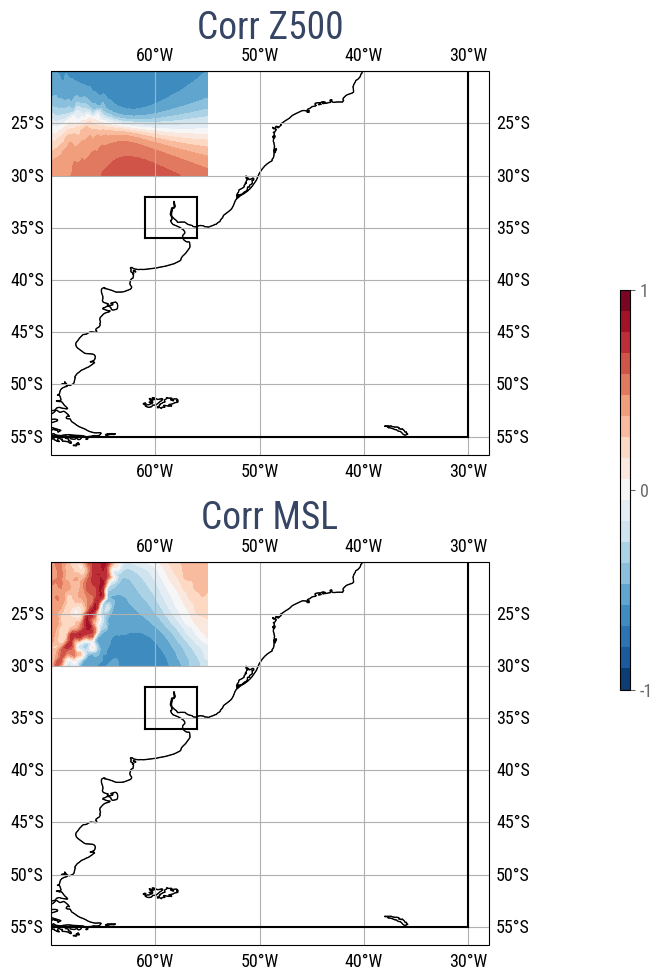

In [ ]:
# Plot map of correlation
fig, ax = plt.subplots(2, 1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,10))
lats = z_data.coord('latitude').points
lons = z_data.coord('longitude').points
con_lev = np.linspace(-1, 1, 20)

c1 = ax[0].contourf(lons, lats, corr_field, levels=con_lev, cmap='RdBu_r', transform=ccrs.PlateCarree())
ax[0].add_feature(cfeature.COASTLINE)
ax[0].coastlines(linewidth=0.4)
ax[0].set_title('Corr Z500')
ax[0].gridlines(draw_labels=True)
my.plot_box(ax[0], impact_domain_iris)
my.plot_box(ax[0], z500_domain)

c1 = ax[1].contourf(lons, lats, corr_field2, levels=con_lev, cmap='RdBu_r', transform=ccrs.PlateCarree())
ax[1].add_feature(cfeature.COASTLINE)
ax[1].coastlines(linewidth=0.4)
ax[1].set_title('Corr MSL')
ax[1].gridlines(draw_labels=True)
my.plot_box(ax[1], impact_domain_iris)
my.plot_box(ax[1], slp_domain)

fig.subplots_adjust(right=0.8)
cax = fig.add_axes([0.85, 0.3, 0.01, 0.4])
cbar = fig.colorbar(c1, cax=cax, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels(['-1', '0', '1'])
plt.tight_layout()

In [ ]:
## To ensure the domain adequately captures the sclae required for it to be the large-scale dynamics we are assessing, not local level patterns, this section checks the ratio of 'red' to 'blue'. 
# There may be cases where blue dominated the correlation (i.e. negative correlation, which would be expected for rainfall where low-pressure is likely to dominate high rainfall)
# Thus teh final line would need changing:
# print('SLP Blue: ',blue, ' Red: ', red, ' Ratio: ', red/(red+blue)) 
# Ratio required - around 25% (.2 to .3)

## This bit could be used to automate the region: find point of highest corr and then find box that gives 20:80 red:blue
X = z_data[0,:,:] 
X.data = corr_field
Y = my.extract_region(X, z500_domain)

a,b = np.shape(Y.data)
blue = 0
red = 0
for i in np.arange(a):
 for j in np.arange(b):
  if Y.data[i,j] < 0:
   blue +=1
  else:
   red +=1

print('Z500 Blue: ',blue, ' Red: ', red, ' Ratio: ', blue/(red+blue)) # want val ~.2

X = z_data[0,:,:] 
X.data = corr_field2
Y = my.extract_region(X, slp_domain)

a,b = np.shape(Y.data)
blue = 0
red = 0
for i in np.arange(a):
 for j in np.arange(b):
  if Y.data[i,j] < 0:
   blue +=1
  else:
   red +=1

print('SLP Blue: ',blue, ' Red: ', red, ' Ratio: ', blue/(red+blue)) # want val .2-.3

Z500 Blue:  1264  Red:  1176  Ratio:  0.5180327868852459
SLP Blue:  1367  Red:  1073  Ratio:  0.5602459016393443


In [ ]:
# Summary print out
print('Summary: identify analogues domain')
print('Event definition:')
print('     Date: ', event_date)
print('     Hazard: ', parameter)
print('     Impact domain: ', impact_domain)
# print('     Months assessed: ', months)
print('     Months assessed: ', ['None'])
print('RESULT:')
print('    Z500 domain:', z500_domain)
print('    MSL domain:', slp_domain)


Summary: identify analogues domain
Event definition:
     Date:  2023-03-11 00:00:00
     Hazard:  Tmean
     Impact domain:  (-61, -36, -56, -32)
     Months assessed:  ['None']
RESULT:
    Z500 domain: [-20, -55, -30, -70]
    MSL domain: [-20, -55, -30, -70]


## 3.10 Assess which circulation variable to use – msl or Z500:
- a. Action: run script C3S02_analogues_VariableChoice.ipynb
    - i. Requires input of the initial variables (determined in Step 3.9c)
    - ii. Software creates lists of analogues and calculates the impact index, produces violin plots and number of analogues plot (Supp.Fig.2 and 3; see Figures description section)
- b. Action: check the final text output, which shows the details of the event and provides input for the next Step (analogue variable Z500 or msl
    - i. Note: the output provides information assuming both a hot or heavy precipitation (high values) and cold (low values) extreme, ensure the correct result is chosen for next step.

In [ ]:
# subset the single day of the event

event_Haz = gdf_to_cube(subset_gdf(gr_daily, datetime_col="valid_time", date_range=(event_date, event_date))) #my.reanalysis_data_single_date(Haz, date)

z500_event_cube = gdf_to_cube_z500(subset_gdf(z500_daily, datetime_col="valid_time", date_range=(event_date, event_date))) #my.reanalysis_data_single_date('msl', date)
# z500_daily_cube = z500_daily_cube[:, 0, :, :]

slp_event_cube = gdf_to_cube_slp(subset_gdf(slp_daily, datetime_col="valid_time", date_range=(event_date, event_date))) #my.reanalysis_data_single_date('z500', date)

In [ ]:
def cube_to_numpy(cube):
    data = cube.data
    lat = cube.coord('latitude').points
    lon = cube.coord('longitude').points
    time = cube.coord('time').points
    return data, time, lat, lon

In [ ]:
def euclidean_distance(field, event):
    '''
    Returns list of D
    Inputs required:
      field = single cube of analogues field.
      event = cube of single day of event to match.
      BOTH MUST HAVE SAME DIMENSIONS FOR LAT/LON
      AREA WEIGHTING APPLIED
    '''
    D= [] # to be list of all euclidean distances
    if event.coord('latitude').has_bounds():
        pass
    else:
        event.coord('latitude').guess_bounds()
    if event.coord('longitude').has_bounds():
        pass
    else:
        event.coord('longitude').guess_bounds()
    weights=iris.analysis.cartography.area_weights(event)
    event=event*weights
    a, b, c =np.shape(field) 
    # d= np.array([weights]*a) 
    d = np.array(weights*a) 
    field=field*d 
    XA= event.data.reshape(b*c,1)
    XB = field.data.reshape(np.shape(field.data)[0],b*c,1)
    for Xb in XB:
        D.append(np.sqrt(np.sum(np.square(XA-Xb)))) 
    return D

In [ ]:
def analogue_dates_v2(event, reanalysis_cube, region, N):
    '''
    '''
    def cube_date_to_string(cube_date : tuple) -> tuple:
        year,month,day,time = cube_date
        return str(year)+str(month).zfill(2)+str(day).zfill(2), time
    E = my.extract_region(event, region)
    reanalysis_cube = my.extract_region(reanalysis_cube, region)
    D = euclidean_distance(reanalysis_cube, E)
    date_list = []
    time_list = []
    for i in np.arange(N):
        #print(i)
        I = np.sort(D)[i]
        for n, each in enumerate(D):
            if I == each:
                a1 = n
        date, time = cube_date_to_string(my.cube_date(reanalysis_cube[a1,...]))
        date_list.append(date)
        date_list2 = my.date_list_checks(date_list, days_apart=5)
    return date_list2

In [ ]:
def impact_index(cube, II_domain):
    '''
    Calculates the impact index over the cube
    II_domain: spatial extent of index
    '''
    cube = my.extract_region(cube, II_domain)
    if not cube.coord('latitude').has_bounds():
        cube.coord('latitude').guess_bounds()
    if not cube.coord('longitude').has_bounds():
        cube.coord('longitude').guess_bounds()
    grid_areas = iris.analysis.cartography.area_weights(cube)
    cube.data = ma.masked_invalid(cube.data)
    return cube.collapsed(('longitude','latitude'),iris.analysis.MEAN,weights=grid_areas).data

In [ ]:
# anaomaly period output for cubes

# cube with daily values, cube of just the event, variable used, date of the event, region, number of analogues
def anomaly_period_outputs(cube_daily, cube_event, date, region, N):

    # cube_daily = cube_daily[:, 0, :, :]  # shape = (time, lat, lon)
    # multiple days
    cube_daily = cube_daily - cube_daily.collapsed(['latitude', 'longitude'], iris.analysis.MEAN) # event for anavar to plot (fig a)

    # cube_event = cube_event[:, 0, :, :]  # shape = (time, lat, lon)
    # single day
    cube_event = cube_event - cube_event.collapsed(['latitude', 'longitude'], iris.analysis.MEAN) # event for anavar to plot (fig a)

    P1_dates = my.analogue_dates_v2(cube_event, cube_daily, region, N*5)[:N]

    if str(date[0])+str("{:02d}".format(list(calendar.month_abbr).index(date[1])))+str(date[2]) in P1_dates: # Remove the date being searched for
        P1_dates.remove(str(date[0])+str("{:02d}".format(list(calendar.month_abbr).index(date[1])))+str(date[2]))
        
    return P1_dates

In [ ]:
### Lists of analogues for all combination
N = 1
# dumb iris date format
date = [2023, "Mar", 11]

dates_slp = anomaly_period_outputs(slp_daily_cube, slp_event_cube, date, impact_domain_iris, N)
dates_z500 = anomaly_period_outputs(z500_daily_cube, z500_event_cube, date, impact_domain_iris, N)


AttributeError: 'NoneType' object has no attribute 'intersection'

In [ ]:
# Calculate the Impact Index for all analogue dates and the event
II_event = my.impact_index(event_Haz, import_domain_iris)

impact_cube = gr_daily_cube # my.reanalysis_data(Haz, Y1, Y2, months)
II_z500 = []
daily_analogues = my.analogues_list(impact_cube, dates_z500)  
for each in daily_analogues:
    II_z500.append(my.impact_index(each, import_domain_iris))

II_msl = []
daily_analogues = my.analogues_list(impact_cube, dates_slp)  
for each in daily_analogues:
    II_msl.append(my.impact_index(each, import_domain_iris))

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(


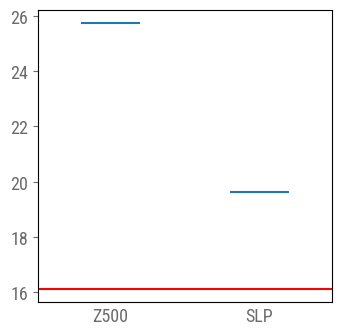

In [ ]:
# Violin Plot (to visually check the result)
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(3.8,3.8))
plots = axs.violinplot([II_z500[:30], II_msl[:30]], showmeans=True, showextrema=False, widths = .8)
axs.axhline(II_event, color='r', label = 'Event')
#axs.text(2.9,28.7,'Observed Event',color='r')
axs.set_xticks([1, 2], labels=['Z500', 'SLP'])
axs.tick_params(axis='x', length=0)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'Choice of circulation variable (which is higher?)')

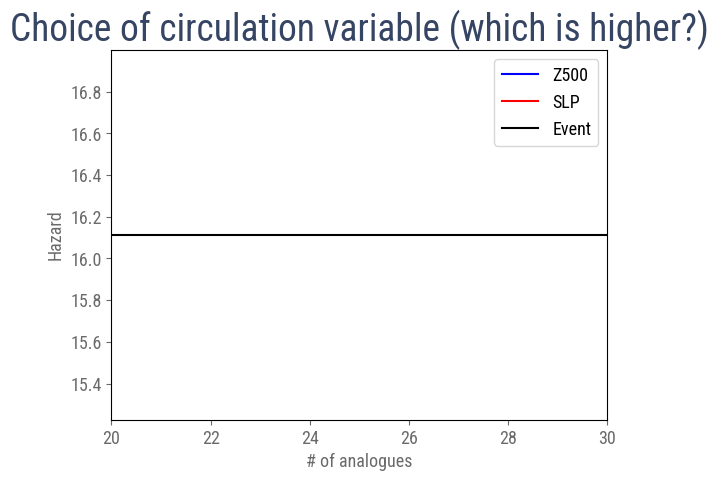

In [ ]:
# Shown for larger range of analogue proportions
meanT = []
for i in np.arange(len(II_z500)):
    meanT.append(np.mean(II_z500[:i]))

plt.plot(meanT, 'b', label = 'Z500')

meanT = []
for i in np.arange(len(II_msl)):
    meanT.append(np.mean(II_msl[:i]))

plt.plot(meanT, 'r', label = 'SLP')
plt.xlim([20, 30]) # 30 = N
plt.axhline(II_event, color='k', label = 'Event')
plt.legend() 
plt.ylabel('Hazard')
plt.xlabel('# of analogues')
plt.title('Choice of circulation variable (which is higher?)')

In [ ]:
# Summary print out
print('Summary: identify circulation variable')
print('Event definition:')
print('     Date: ', event_date)
print('     Hazard: ', parameter)
print('     Impact domain: ', impact_domain)
# print('     Months assessed: ', months)
print('     Number of analogues: ', N)
print('     Z500 domain:', impact_domain)
print('     MSL domain:', impact_domain)
print('Results:')

u, p = stats.ttest_ind(II_z500, II_msl, equal_var=False, alternative='two-sided')
if np.mean(II_z500) > np.mean(II_msl):
    print('Recommend using Z500')
else:
    print('Recommend using SLP')

if p < 0.05:
    print('  Statistically significant difference')
else:
    print('  Difference is not statistically significant')

## 3.11 Assess composites of analogues:
- a. Action: run script C3S03_analogues_Composites.ipynb
    - i. Requires input of initial variables
        - 11.a.i.1. analogue variable (from Step 3.10b)
        - 11.a.i.2. analogue domain (from Step 3.9c, choose the domain corresponding to the analogue variable)
    - ii. Software produces composite figures (Fig.Supp.4 & Fig.1 (See Figures description section))
- b. Software uses 1% of analogues
- c. Software uses time slices of 1950-1980 and 1994-2024 (potentially change 2nd time slice by a year after 2025)
- d. Software calculates analogue composites
- e. analogue composites
    - i. Action: manually ensure that the analogue composites shows analogues which closely resemble the observed event.
        - 11.e.i.1. Do subplots b and c look similar to a? Do they show the same large-scale circulation patterns?
        - 11.e.i.2. If not, re-check input variables, and Steps 3.9 and 3.10,
        - 11.e.i.3. Else consider if the event is too dynamically unusual to use analogues.
    - ii. In case the circulation situation is found to be too unique for analogues to describe past and present composites, stop here and describe in the Scientific Report Sect. XX that analogues could not be used since the circulation is too unique.
- f. Software plots z500, msl, tp, t2m of event, past composite, present day composite and difference including significance.
    - i. Action: check the final text output to ensure correct inputs
    - ii. Action: interpretation of results:
        - 11.f.ii.1. Focus on the chosen circulation variable and the event variable, the other figures may give some guidance but do not need interpretation
        - 11.f.ii.2. Notable differences, such as statistically significant differences between past and present in regions of high or low pressure (likely to influence the meteorological hazard) should be noted in the report text (next Step).
        - 11.f.ii.3. Note – the fields are not anomaly fields, therefore the changes include both thermodynamical and dynamical changes. There is likely to be an increase in temperature through time – at least partly explainable by increasing global temperatures.
    - iii. Copy the final Figure to the scientific report, to become the first analogues figure
- g. Edit report text to detail the conclusions (see Report template).

## 3.12 Assess change in frequency:
- a. Action: run script C3S04_analogues_Frequency.ipynb
    - i. Requires input of initial variables (date, analogue domain, circulation variable)
    - ii. Software produces figure of change in frequency of similar circulation analogues (Fig.2; See Figures description section)
- b. Software calculates Euclidean distance to all events and identifies value of closest analogues within all data for 5%, 10% and 20% thresholds.
- c. Software produces figure of frequencies of closest analogues of 5%, 10%, 20%, including 10- year rolling mean, linear trend and p-values
- d. Copy this Figure to the scientific report to become the second analogues figure
- e. Note the final text output, providing guidance for the report
    - i. Increasing / No trend / Decreasing
    - ii. Significant / Not significant
- f. Edit report text to detail the conclusions (see Report template):

## 3.13 For precipitation cases only, assess postage stamp figures:
- a. Note that science is still under development, check later whether any changes need to be made.
- b. If the event is a rainfall extreme the analogues are unlikely to show similar rainfall fields to the observed event. This is because the large-scale circulation alone is not a good predictor of rainfall, other drivers are also important. For rainfall events an additional figure should be produced to show the spread in rainfall patterns in the analogues.
- c. Action: run script C3S05_analogues_postagestamps.ipynb
    - i. Requires input of initial variables (date, analogue domain, circulation variable)
    - ii. For plotting purposes use analogues number of N=19
- nd. Software calculates the analogue dates for each period.
- e. Software plots precipitation on the dates of the 19 past and 19 present analogues (plus theevent) that are closest to the event circulation
- f. Action: Check whether the majority of the analogues show rainfall over the event region,which suggests we can use analogues in this rainfall events to conclude on changes inrainfall.
    - i. If the majority (at least in the present day climate) shows rainfall in the same region ason the event day, we can use the conclusions on precipitation changes
    - ii. If at least half of the analogues show rainfall close to the same region as on the eventday, we can use the conclusion on precipitation changes, but have less confidence inconclusions
    - iii. If the majority shows different or no rainfall we can conclude that the analoguesanalysis is not useful to describe rainfall in this case. We can conclude that rainfallpatterns are not always the same, but conclusions about circulation changes are valid.
- g. Action: copy the two output figures (past and present analogues) into the report to become the third analogues figure and describe conclusion.

yellow highlighted steps needed?